<a href="https://colab.research.google.com/github/sahilmishra-tech/game-behavior-risk-classifier/blob/main/Another_copy_of_Sample_ML_Submission_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Game Classifier





##### **Project Type**    - Classification
##### **Contribution**    - Individual

# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/sahilmishra-tech/game-behavior-risk-classifier

# **Problem Statement**


**Write Problem Statement Here.**

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset Loading

In [ ]:
# Load Dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/gaming_addiction.csv')


### Dataset First View

In [ ]:
# Dataset First Look
df.head()

,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.0,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.0,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.0,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.0,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.0,0.585,0.867


### Dataset Rows & Columns count

In [ ]:
# Dataset Rows & Columns count
df.shape

(250, 49)

### Dataset Information

In [ ]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   user_id                      250 non-null    object 
 1   age                          250 non-null    int64  
 2   gender                       250 non-null    object 
 3   country                      250 non-null    object 
 4   occupation                   250 non-null    object 
 5   income_level                 250 non-null    object 
 6   years_gaming                 250 non-null    int64  
 7   preferred_genre              250 non-null    object 
 8   platform                     250 non-null    object 
 9   device_type                  250 non-null    object 
 10  rank_tier                    250 non-null    object 
 11  daily_playtime_hours         250 non-null    float64
 12  weekly_play_sessions         250 non-null    int64  
 13  late_night_sessions_

#### Duplicate Values

In [ ]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [ ]:
# Missing Values/Null Values Count
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
occupation,0
income_level,0
years_gaming,0
preferred_genre,0
platform,0
device_type,0


In [ ]:
# Visualizing the missing values

### What did you know about your dataset?

Answer Here

## ***2. Understanding Your Variables***

In [ ]:
# Dataset Columns
df.shape[1]

49

In [ ]:
# Dataset Describe
df.describe()

,age,years_gaming,daily_playtime_hours,weekly_play_sessions,late_night_sessions_hours,weekend_playtime_hours,consecutive_hours_max,multiplayer_ratio,toxic_chat_reports,rage_quit_frequency,...,missed_deadlines,productivity_drop_percent,absenteeism_days,internet_speed_mbps,screen_time_total_hours,addiction_score,addiction_binary,burnout_probability,mental_health_risk_score,churn_probability
count,250.000000,250.000000,250.000000,250.000000,250.0000,250.000000,250.000000,250.000000,250.000000,250.000000,...,250.000000,250.000000,250.00000,250.000000,250.000000,250.00000,250.000000,250.000000,250.000000,250.000000
mean,22.160000,9.668000,6.153200,7.056000,2.1024,8.368400,9.714800,0.462240,2.948000,1.896000,...,2.828000,15.986400,5.52400,99.253200,8.239600,38.74448,0.168000,0.996856,0.509640,0.795556
std,5.455037,5.460866,2.656902,3.517721,1.2007,4.085876,4.828877,0.227391,5.451621,2.353581,...,2.088027,10.581607,3.14212,55.057918,2.894558,11.74977,0.374616,0.043240,0.140448,0.120904
min,13.000000,1.000000,0.500000,1.000000,0.0000,0.500000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,5.000000,1.200000,12.28000,0.000000,0.320000,0.120000,0.150000
25%,18.000000,6.000000,4.225000,4.000000,1.1250,5.600000,5.525000,0.300000,0.000000,0.000000,...,1.000000,8.150000,3.00000,61.375000,6.200000,29.88250,0.000000,1.000000,0.406250,0.732250
50%,22.000000,9.000000,6.450000,7.000000,2.1000,8.150000,10.100000,0.450000,1.000000,1.000000,...,3.000000,15.900000,6.00000,99.150000,8.200000,39.87500,0.000000,1.000000,0.515000,0.808000
75%,27.000000,14.750000,8.175000,10.000000,3.0000,10.850000,13.175000,0.630000,2.000000,3.000000,...,4.000000,22.975000,8.00000,133.575000,10.500000,47.11000,0.000000,1.000000,0.600000,0.878000
max,40.000000,25.000000,11.900000,15.000000,5.2000,20.000000,20.600000,1.000000,32.000000,10.000000,...,8.000000,44.200000,14.00000,255.500000,15.100000,68.00000,1.000000,1.000000,0.920000,1.000000


### Variables Description

Answer Here

### Check Unique Values for each variable.

In [ ]:
# Check Unique Values for each variable.
df.nunique()

,0
user_id,250
age,25
gender,4
country,15
occupation,5
income_level,5
years_gaming,23
preferred_genre,10
platform,5
device_type,6


## 3. ***Data Wrangling***

### Data Wrangling Code

In [ ]:
df['addiction_binary'].value_counts()

,count
addiction_binary,
0,208
1,42


In [ ]:
df['subscription_status'] = df['subscription_status'].fillna('None')
df['depression_indicator'] = df['depression_indicator'].fillna(df['depression_indicator'].median())
df['gpa_or_performance_score'] = df['gpa_or_performance_score'].fillna(df['gpa_or_performance_score'].mean())

### What all manipulations have you done and insights you found?

Answer Here.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

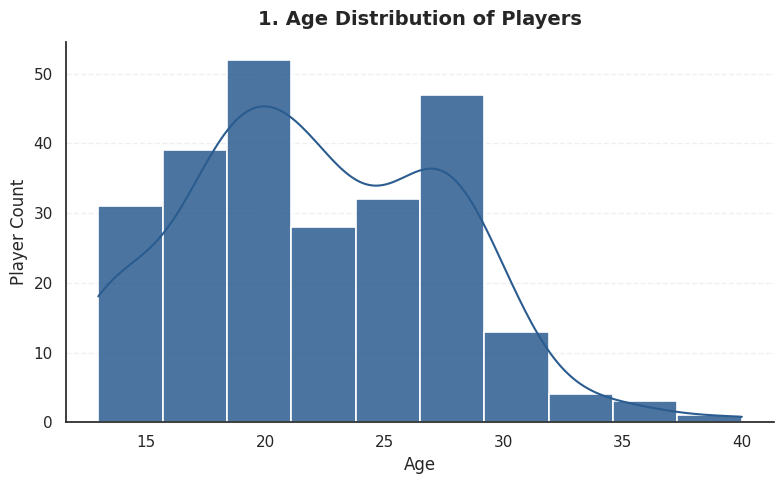

In [ ]:
sns.set_theme(style="white")
plt.figure(figsize=(8, 5))

sns.histplot(df['age'], kde=True, color='#2b5c8f', edgecolor='white', linewidth=1.2, alpha=0.85)
sns.despine()

plt.title('1. Age Distribution of Players', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Player Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('graph_1_age_distribution.png', dpi=300)
plt.show()

#### Chart - 2

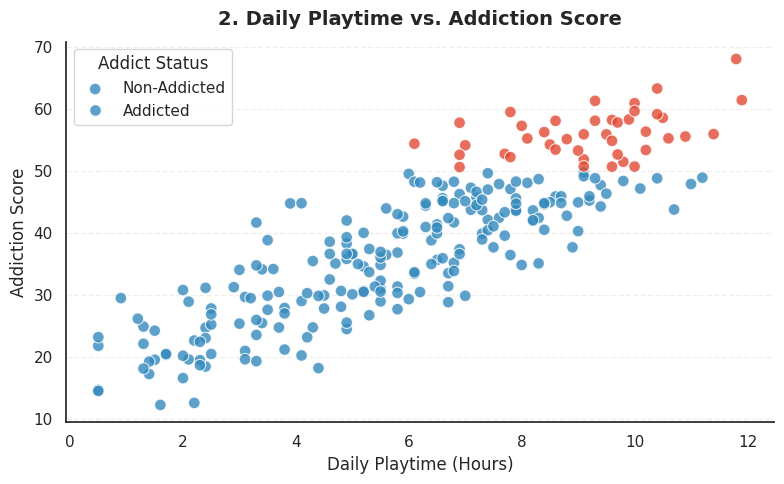

In [ ]:
# Chart - 2 visualization code
sns.set_theme(style="white")
plt.figure(figsize=(8, 5))

sns.scatterplot(x='daily_playtime_hours', y='addiction_score', hue='addiction_binary', data=df,
                palette={0: '#348abd', 1: '#e24a33'}, alpha=0.8, s=70, edgecolor='w', linewidth=0.8)
sns.despine()

plt.title('2. Daily Playtime vs. Addiction Score', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Daily Playtime (Hours)', fontsize=12)
plt.ylabel('Addiction Score', fontsize=12)
plt.legend(title='Addict Status', labels=['Non-Addicted', 'Addicted'], loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('graph_2_playtime_vs_score.png', dpi=300)
plt.show()

#### Chart - 3

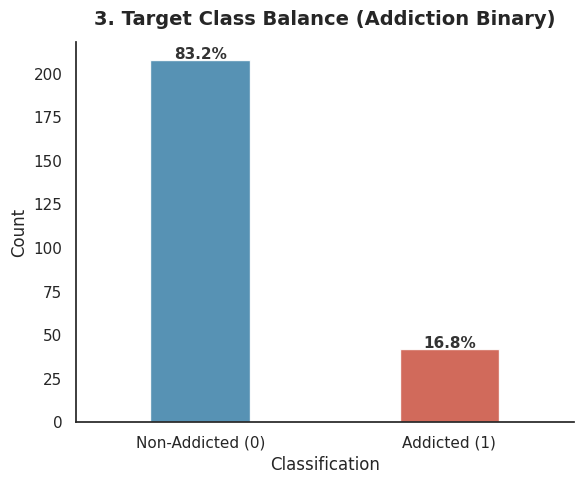

In [ ]:
# Chart - 3 visualization code
sns.set_theme(style="white")
plt.figure(figsize=(6, 5))

ax3 = sns.countplot(x='addiction_binary', hue='addiction_binary', data=df, palette=['#348abd', '#e24a33'], alpha=0.9, width=0.4, legend=False
)
sns.despine()

plt.title('3. Target Class Balance (Addiction Binary)', fontsize=14, fontweight='bold', pad=12)

plt.xticks(ticks=[0, 1], labels=['Non-Addicted (0)', 'Addicted (1)'])

plt.xlabel('Classification', fontsize=12)
plt.ylabel('Count', fontsize=12)

total = len(df)
for p in ax3.patches:
    if p.get_height() > 0:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        ax3.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height() + 3),
                    ha='center', va='center', fontsize=11, fontweight='bold', color='#333333')

plt.tight_layout()
plt.savefig('graph_3_class_balance.png', dpi=300)
plt.show()

#### Chart - 4

/tmp/ipykernel_570/3373169410.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='addiction_score', y='preferred_genre', data=df, order=genre_order, palette='coolwarm', width=0.6)


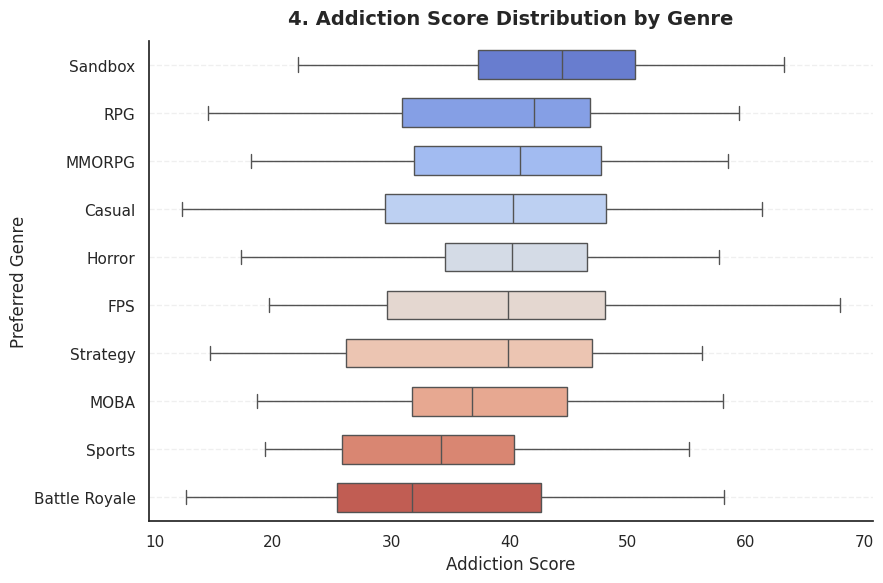

In [ ]:
# Chart - 4 visualization code
sns.set_theme(style="white")
plt.figure(figsize=(9, 6))

genre_order = df.groupby('preferred_genre')['addiction_score'].median().sort_values(ascending=False).index

sns.boxplot(x='addiction_score', y='preferred_genre', data=df, order=genre_order, palette='coolwarm', width=0.6)
sns.despine()

plt.title('4. Addiction Score Distribution by Genre', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Addiction Score', fontsize=12)
plt.ylabel('Preferred Genre', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('graph_4_genre_vs_score.png', dpi=300)
plt.show()

#### Chart - 5

/tmp/ipykernel_570/2434741862.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr.values, y=corr.index, palette='crest_r', alpha=0.9)


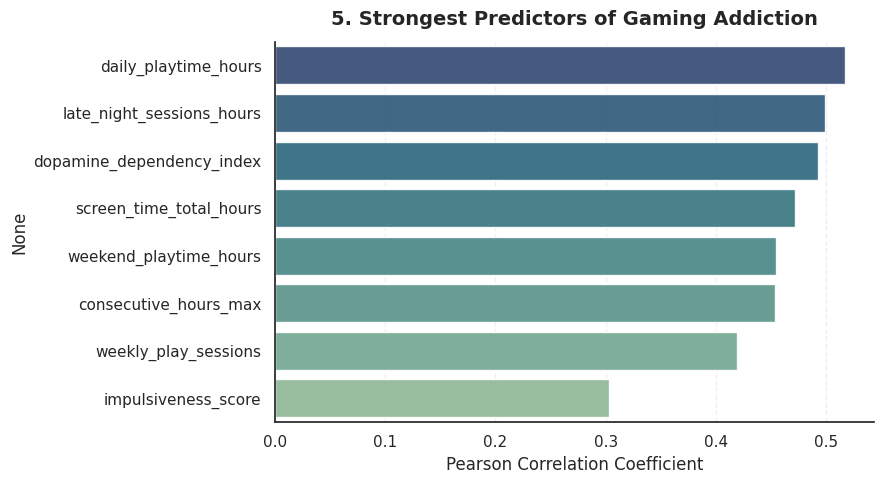

In [ ]:
# Chart - 5 visualization code
sns.set_theme(style="white")
plt.figure(figsize=(9, 5))

numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_cols].corr()['addiction_binary'].drop(['addiction_binary', 'addiction_score'], errors='ignore').sort_values(ascending=False).head(8)

sns.barplot(x=corr.values, y=corr.index, palette='crest_r', alpha=0.9)
sns.despine()

plt.title('5. Strongest Predictors of Gaming Addiction', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('graph_5_feature_correlations.png', dpi=300)
plt.show()

#### Chart - 6

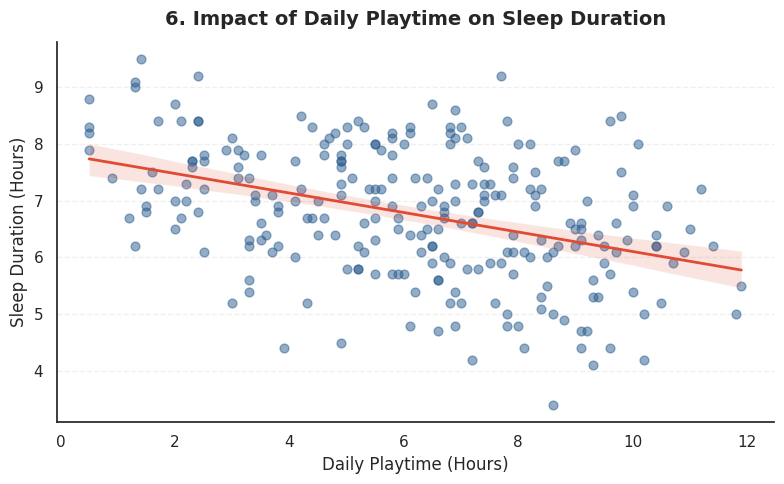

In [ ]:
# Chart - 6 visualization code
plt.figure(figsize=(8, 5))

sns.regplot(x='daily_playtime_hours', y='sleep_hours', data=df,
            scatter_kws={'alpha':0.5, 'color':'#2b5c8f', 's':40}, line_kws={'color':'#e24a33', 'linewidth':2})
sns.despine()

plt.title('6. Impact of Daily Playtime on Sleep Duration', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Daily Playtime (Hours)', fontsize=12)
plt.ylabel('Sleep Duration (Hours)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('graph_6_sleep_vs_playtime.png', dpi=300)
plt.show()

## ***6. Feature Engineering & Data Pre-processing***

In [ ]:
df.isnull().sum()

,0
user_id,0
age,0
gender,0
country,0
occupation,0
income_level,0
years_gaming,0
preferred_genre,0
platform,0
device_type,0


In [ ]:
df = df.drop(columns=['user_id', 'addiction_severity', 'addiction_score'])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score,classification_report

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 46 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          250 non-null    int64  
 1   gender                       250 non-null    object 
 2   country                      250 non-null    object 
 3   occupation                   250 non-null    object 
 4   income_level                 250 non-null    object 
 5   years_gaming                 250 non-null    int64  
 6   preferred_genre              250 non-null    object 
 7   platform                     250 non-null    object 
 8   device_type                  250 non-null    object 
 9   rank_tier                    250 non-null    object 
 10  daily_playtime_hours         250 non-null    float64
 11  weekly_play_sessions         250 non-null    int64  
 12  late_night_sessions_hours    250 non-null    float64
 13  weekend_playtime_hou

In [ ]:

categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
x = df.drop('addiction_binary', axis=1)
y = df['addiction_binary']
x_smote, y_smote = SMOTE().fit_resample(x, y)

In [ ]:
y_smote.value_counts()

,count
addiction_binary,
0,208
1,208


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_smote, y_smote, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,precision_score,recall_score,f1_score

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
model = LogisticRegression()
model.fit(x_train, y_train)

prediction = model.predict(x_test)

print("Accuracy :", accuracy_score(y_test, prediction))

Accuracy : 0.9642857142857143


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [ ]:
print('Train Confusion Matrix :-\n',confusion_matrix(y_train,train_pred))
print('Train Accuracfy :-',accuracy_score(y_train,train_pred))
print('Train Precision Score :-',precision_score(y_train,train_pred))
print('Train Recall Score :-',recall_score(y_train,train_pred))

Train Confusion Matrix :-
 [[158   8]
 [  0 166]]
Train Accuracfy :- 0.9759036144578314
Train Precision Score :- 0.9540229885057471
Train Recall Score :- 1.0


In [ ]:
print('Test confusion matrix :-\n',confusion_matrix(y_test,test_pred))
print('Test Accuracy :-',accuracy_score(y_test,test_pred))
print('Test Precision Score :-',precision_score(y_test,test_pred))
print('Test Recall Score :-',recall_score(y_test,test_pred))

Test confusion matrix :-
 [[39  3]
 [ 0 42]]
Test Accuracy :- 0.9642857142857143
Test Precision Score :- 0.9333333333333333
Test Recall Score :- 1.0


### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Visualizing evaluation Metric Score chart
model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(x_train, y_train)

prediction = model.predict(x_test)
print("Accuracy :", accuracy_score(y_test, prediction))

Accuracy : 0.9047619047619048


In [ ]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [ ]:
print('Train Confusion Matrix :-\n',confusion_matrix(y_train,train_pred))
print('Train Accuracfy :-',accuracy_score(y_train,train_pred))
print('Train Precision Score :-',precision_score(y_train,train_pred))
print('Train Recall Score :-',recall_score(y_train,train_pred))

Train Confusion Matrix :-
 [[158   8]
 [  0 166]]
Train Accuracfy :- 0.9759036144578314
Train Precision Score :- 0.9540229885057471
Train Recall Score :- 1.0


In [ ]:
print('Test confusion matrix :-\n',confusion_matrix(y_test,test_pred))
print('Test Accuracy :-',accuracy_score(y_test,test_pred))
print('Test Precision Score :-',precision_score(y_test,test_pred))
print('Test Recall Score :-',recall_score(y_test,test_pred))

Test confusion matrix :-
 [[36  6]
 [ 2 40]]
Test Accuracy :- 0.9047619047619048
Test Precision Score :- 0.8695652173913043
Test Recall Score :- 0.9523809523809523


### ML Model - 3

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
prediction = model.predict(x_test)
print("Accuracy :", accuracy_score(y_test, prediction))

Accuracy : 0.9523809523809523


In [ ]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [ ]:
print('Train Confusion Matrix :-\n',confusion_matrix(y_train,train_pred))
print('Train Accuracfy :-',accuracy_score(y_train,train_pred))
print('Train Precision Score :-',precision_score(y_train,train_pred))
print('Train Recall Score :-',recall_score(y_train,train_pred))

Train Confusion Matrix :-
 [[166   0]
 [  0 166]]
Train Accuracfy :- 1.0
Train Precision Score :- 1.0
Train Recall Score :- 1.0


In [ ]:
print('Test confusion matrix :-\n',confusion_matrix(y_test,test_pred))
print('Test Accuracy :-',accuracy_score(y_test,test_pred))
print('Test Precision Score :-',precision_score(y_test,test_pred))
print('Test Recall Score :-',recall_score(y_test,test_pred))

Test confusion matrix :-
 [[39  3]
 [ 1 41]]
Test Accuracy :- 0.9523809523809523
Test Precision Score :- 0.9318181818181818
Test Recall Score :- 0.9761904761904762


# **Conclusion**

In [ ]:
import pickle

In [ ]:
with open("pred.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***